# PSet 5: Aiyagari GE Steady State

Solve the Aiyagari (1994) model in general equilibrium using the `hetmacro` package.

**Outline:**
1. Setup and parameterization (PS5 calibration)
2. Capital supply and demand curves
3. GE steady state: Brent vs bisection root finding
4. Multi-solver comparison (EGM, GridVFI, PFI, HowardGrid, HowardImprovement, CollocationVFI_Spline)
5. Diagnostics: policy functions, wealth distribution, Euler residuals

In [1]:
import importlib
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Repo-root detection
REPO_ROOT = None
for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (p / "hetmacro").exists():
        REPO_ROOT = p
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate repository root containing 'hetmacro'.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import hetmacro.models.aiyagari
import hetmacro.household
import hetmacro.solvers.egm
import hetmacro.solvers.grid_vfi
import hetmacro.solvers.policy_iteration
import hetmacro.solvers.howard_grid
import hetmacro.solvers.howard
import hetmacro.solvers.collocation_vfi
importlib.reload(hetmacro.models.aiyagari)
importlib.reload(hetmacro.household)
importlib.reload(hetmacro.solvers.egm)
importlib.reload(hetmacro.solvers.grid_vfi)
importlib.reload(hetmacro.solvers.policy_iteration)
importlib.reload(hetmacro.solvers.howard_grid)
importlib.reload(hetmacro.solvers.howard)
importlib.reload(hetmacro.solvers.collocation_vfi)

from hetmacro.grids import make_asset_grid
from hetmacro.income_process import RouwenhorstIncome
from hetmacro.household import Household, SolvedPolicy
from hetmacro.markov import stationary_distribution
from hetmacro.models.aiyagari import (
    firm_k_demand, firm_wage,
    capital_supply_curve, solve_aiyagari_ge,
)
from hetmacro.solvers import (
    EGM, GridVFI, PolicyFunctionIteration,
    HowardGrid, HowardImprovement,
    CollocationVFI_Spline,
)

print("Imports OK")

Imports OK


## 1. Parameters and Setup

PS5 calibration: $\beta = 0.99$, $\theta = 1.5$ (CRRA), $\rho = 0.99$, $\sigma_e = 0.10$,
$\alpha = 0.35$, $\delta = 0.02$. Asset grid: 501 points on $[0, 2500]$, power-spaced.
Income: Rouwenhorst with 11 states, normalized so $E[e] = 1$.

In [2]:
# PS5 parameterization
beta = 0.99
gamma = 1.5          # CRRA (theta in PS5)
rho = 0.99
sigma_e = 0.10
alpha = 0.35
delta = 0.02

# Grid
nk = 501
ne = 11
k_min, k_max = 0.0, 2500.0

a_grid = make_asset_grid(k_min, k_max, nk, curvature=2.0)

# Income process (Rouwenhorst)
income = RouwenhorstIncome.from_ar1(n=ne, rho=rho, sigma=sigma_e)

# Normalize z_grid so E[z] = 1 under stationary distribution
pi_stat = stationary_distribution(income.Pi, method="iterate")
mean_z = float(np.dot(pi_stat, income.z_grid))
income.z_grid = income.z_grid / mean_z

print(f"Asset grid: {nk} points on [{k_min}, {k_max}]")
print(f"Income states: {ne}")
print(f"z_grid range: [{income.z_grid.min():.4f}, {income.z_grid.max():.4f}]")
print(f"E[z] under stationary dist: {np.dot(pi_stat, income.z_grid):.6f}")

# Interest rate bounds: r must be below 1/beta - 1 for convergence
r_upper = 1.0 / beta - 1.0
print(f"\n1/beta - 1 = {r_upper:.6f}")
r_bounds = (-0.01, r_upper - 1e-4)
print(f"Search bounds: {r_bounds}")

Asset grid: 501 points on [0.0, 2500.0]
Income states: 11
z_grid range: [0.0828, 7.3338]
E[z] under stationary dist: 1.000000

1/beta - 1 = 0.010101
Search bounds: (-0.01, 0.010001010101010167)


## 2. Capital Supply and Demand Curves

The demand curve $K_d(r) = (\alpha / (r + \delta))^{1/(1-\alpha)}$ is analytical and
downward-sloping. The supply curve $K_s(r)$ is the aggregate asset holdings
from the household problem at each interest rate, and is upward-sloping.

Interest rates are expressed in **percent per annum (% p.a.)**. With a quarterly model period,
the annualized rate is $r_{\text{ann}} = 400 \times r_q$, where $r_q$ is the quarterly net
return. This follows from the approximation $(1 + r_q)^4 - 1 \approx 4 r_q$ for small $r_q$.

In [3]:
# Compute supply curve on a grid of interest rates
print("Computing capital supply curve (this may take a few minutes)...")
curves = capital_supply_curve(
    solver=EGM(tol=1e-8, max_iter=2000),
    income_process=income,
    a_grid=a_grid,
    beta=beta,
    gamma=gamma,
    alpha=alpha,
    delta=delta,
    n_points=15,
    r_bounds=r_bounds,
    verbose=True,
)
print("Done.")

Computing capital supply curve (this may take a few minutes)...
  [  1/15]  r=-0.010000  K_s=3.5435  K_d=237.4047  excess=-2.3386e+02  (0.51s)
  [  2/15]  r=-0.008571  K_s=4.5093  K_d=193.3155  excess=-1.8881e+02  (0.08s)
  [  3/15]  r=-0.007143  K_s=5.7700  K_d=161.2751  excess=-1.5551e+02  (0.07s)
  [  4/15]  r=-0.005714  K_s=7.4035  K_d=137.1414  excess=-1.2974e+02  (0.09s)
  [  5/15]  r=-0.004285  K_s=9.5208  K_d=118.4364  excess=-1.0892e+02  (0.09s)
  [  6/15]  r=-0.002857  K_s=12.2852  K_d=103.5970  excess=-9.1312e+01  (0.09s)
  [  7/15]  r=-0.001428  K_s=15.9533  K_d=91.5937  excess=-7.5640e+01  (0.09s)
  [  8/15]  r=0.000001  K_s=20.9123  K_d=81.7240  excess=-6.0812e+01  (0.11s)
  [  9/15]  r=0.001429  K_s=27.7684  K_d=73.4938  excess=-4.5725e+01  (0.12s)
  [ 10/15]  r=0.002858  K_s=37.5818  K_d=66.5471  excess=-2.8965e+01  (0.19s)
  [ 11/15]  r=0.004286  K_s=52.3698  K_d=60.6208  excess=-8.2510e+00  (0.18s)
  [ 12/15]  r=0.005715  K_s=76.4990  K_d=55.5176  excess=2.0981e+01  (

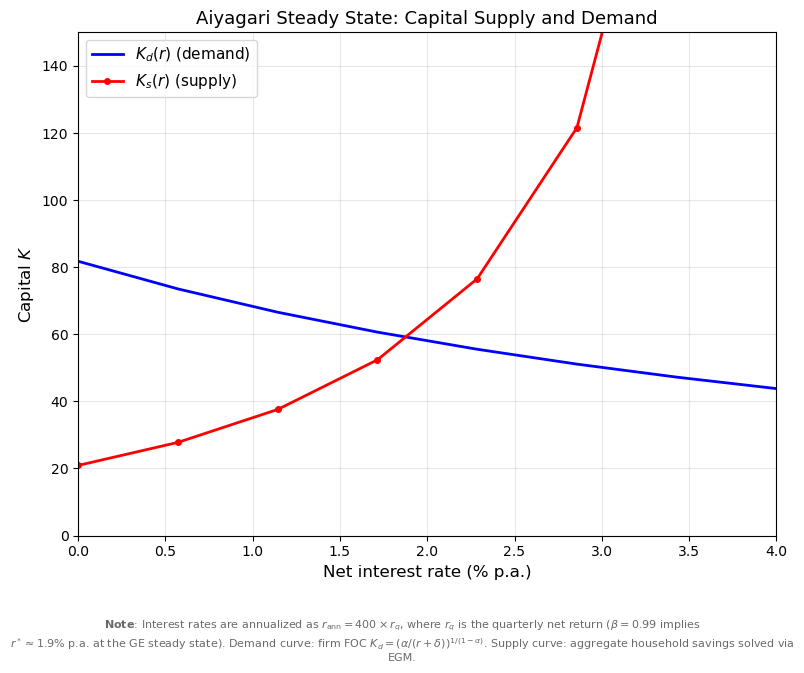

In [10]:
# Plot supply vs demand (interest rates in % p.a.)
r_ann = curves["r"] * 400  # quarterly -> annualized %

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(r_ann, curves["K_demand"], "b-", linewidth=2, label="$K_d(r)$ (demand)")
ax.plot(r_ann, curves["K_supply"], "r-o", linewidth=2, markersize=4, label="$K_s(r)$ (supply)")
ax.set_xlabel("Net interest rate (% p.a.)", fontsize=12)
ax.set_ylabel("Capital $K$", fontsize=12)
ax.set_title("Aiyagari Steady State: Capital Supply and Demand", fontsize=13)
ax.set_xlim(0,4)  # focus on positive r region
ax.set_ylim(0, 150)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")

note = (
    r"$\bf{Note}$: Interest rates are annualized as $r_{\mathrm{ann}} = 400 \times r_q$, "
    r"where $r_q$ is the quarterly net return ($\beta = 0.99$ implies "
    r"$r^* \approx 1.9\%$ p.a. at the GE steady state). "
    r"Demand curve: firm FOC $K_d = (\alpha/(r+\delta))^{1/(1-\alpha)}$. "
    r"Supply curve: aggregate household savings solved via EGM."
)
fig.text(0.5, -0.04, note, ha="center", va="top", fontsize=8,
         wrap=True, color="dimgray",
         bbox=dict(boxstyle="square,pad=0", fc="none", ec="none"),
         transform=fig.transFigure)

plt.tight_layout()
plt.show()

## 3. GE Steady State: Brent vs Bisection

We solve for the equilibrium $r^*$ using two root-finding methods and compare convergence.

In [11]:
# Brent's method
print("=" * 70)
print("Brent's method")
print("=" * 70)
result_brent = solve_aiyagari_ge(
    solver=EGM(tol=1e-8, max_iter=2000),
    income_process=income,
    a_grid=a_grid,
    beta=beta,
    gamma=gamma,
    alpha=alpha,
    delta=delta,
    r_bounds=r_bounds,
    method="brentq",
    verbose=True,
)

Brent's method
  iter   1  r=-0.01000000  K_d=237.4047  K_s=3.5435  excess=-2.3386e+02  (0.08s)
  iter   2  r=0.01000101  K_d=43.7960  K_s=1357.7101  excess=+1.3139e+03  (0.24s)
  iter   3  r=-0.00697795  K_d=158.1464  K_s=5.9375  excess=-1.5221e+02  (0.07s)
  iter   4  r=-0.00192936  K_d=95.5312  K_s=14.5419  excess=-8.0989e+01  (0.11s)
  iter   5  r=0.00403583  K_d=61.5960  K_s=49.2728  excess=-1.2323e+01  (0.16s)
  iter   6  r=0.00504743  K_d=57.8106  K_s=63.6036  excess=+5.7930e+00  (0.18s)
  iter   7  r=0.00472395  K_d=58.9783  K_s=58.4531  excess=-5.2527e-01  (0.25s)
  iter   8  r=0.00475084  K_d=58.8798  K_s=58.8585  excess=-2.1336e-02  (0.18s)
  iter   9  r=0.00475198  K_d=58.8756  K_s=58.8756  excess=+1.9076e-06  (0.19s)
  iter  10  r=0.00475147  K_d=58.8775  K_s=58.8680  excess=-9.4483e-03  (0.15s)
  iter  11  r=0.00475198  K_d=58.8756  K_s=58.8756  excess=+1.9076e-06  (0.18s)

  Converged: r*=0.00475198  K*=58.8756  w*=2.7064  Y*=4.1637  C*=2.9862
  Resource constraint resid

In [12]:
# Bisection method
print("=" * 70)
print("Bisection method")
print("=" * 70)
result_bisect = solve_aiyagari_ge(
    solver=EGM(tol=1e-8, max_iter=2000),
    income_process=income,
    a_grid=a_grid,
    beta=beta,
    gamma=gamma,
    alpha=alpha,
    delta=delta,
    r_bounds=r_bounds,
    method="bisection",
    verbose=True,
)

Bisection method
  iter   1  r=-0.01000000  K_d=237.4047  K_s=3.5435  excess=-2.3386e+02  (0.09s)
  iter   2  r=0.01000101  K_d=43.7960  K_s=1357.7101  excess=+1.3139e+03  (0.30s)
  iter   3  r=0.00000051  K_d=81.7240  K_s=20.9123  excess=-6.0812e+01  (0.17s)
  iter   4  r=0.00500076  K_d=57.9767  K_s=62.8218  excess=+4.8451e+00  (0.25s)
  iter   5  r=0.00250063  K_d=68.1791  K_s=34.7651  excess=-3.3414e+01  (0.43s)
  iter   6  r=0.00375069  K_d=62.7373  K_s=46.0434  excess=-1.6694e+01  (0.42s)
  iter   7  r=0.00437573  K_d=60.2795  K_s=53.5377  excess=-6.7418e+00  (0.24s)
  iter   8  r=0.00468824  K_d=59.1096  K_s=57.9208  excess=-1.1888e+00  (0.28s)
  iter   9  r=0.00484450  K_d=58.5387  K_s=60.3013  excess=+1.7627e+00  (0.18s)
  iter  10  r=0.00476637  K_d=58.8230  K_s=59.0943  excess=+2.7130e-01  (0.45s)
  iter  11  r=0.00472731  K_d=58.9660  K_s=58.5035  excess=-4.6258e-01  (0.38s)
  iter  12  r=0.00474684  K_d=58.8944  K_s=58.7978  excess=-9.6604e-02  (0.26s)
  iter  13  r=0.0047

In [13]:
# Comparison table
print("\nRoot-finder comparison")
print("-" * 70)
print(f"{'Method':<12s} {'r*':>12s} {'K*':>10s} {'Iters':>8s} {'Time(s)':>10s}")
print("-" * 70)
for name, res in [("Brent", result_brent), ("Bisection", result_bisect)]:
    print(f"{name:<12s} {res['r']:12.8f} {res['K']:10.4f} {res['n_iterations']:8d} {res['elapsed']:10.2f}")
print(f"\n|r_brent - r_bisect| = {abs(result_brent['r'] - result_bisect['r']):.2e}")


Root-finder comparison
----------------------------------------------------------------------
Method                 r*         K*    Iters    Time(s)
----------------------------------------------------------------------
Brent          0.00475198    58.8756       11       1.62
Bisection      0.00475198    58.8756       30       7.39

|r_brent - r_bisect| = 8.79e-11


## 4. Multi-Solver GE Comparison

Run the GE solver with each available solver backend and compare equilibrium values and timing.

**Note:** GridVFI and CollocationVFI_Spline are slow (GridVFI ~16 min, Collocation ~9 min per GE solve
on a 501-point grid). Set `SKIP_SLOW = True` below to skip them.

Solvers fall into two families:
- **Continuous $a'$:** EGM, PFI, HowardImprovement, CollocationVFI_Spline — these interpolate
  over the asset grid and agree closely on $r^*$.
- **Discrete $a'$:** GridVFI, HowardGrid — these restrict $a'$ to grid points, making $K_s(r)$
  a step function. This limits root-finding precision and yields a slightly different $r^*$.

In [15]:
SKIP_SLOW = True  # Set False to include GridVFI and CollocationVFI_Spline

solver_specs = [
    ("EGM", EGM(tol=1e-8, max_iter=2000)),
    ("PFI", PolicyFunctionIteration(tol=1e-8, max_iter=500)),
    ("HowardGrid", HowardGrid(tol=1e-8, max_iter=200)),
    ("HowardImprovement", HowardImprovement(n_a_breaks=51, tol=1e-6, max_iter=120, n_warmup=2, verbose=False)),
]

if not SKIP_SLOW:
    solver_specs.insert(1, ("GridVFI", GridVFI(tol=1e-8, max_iter=2000)))
    solver_specs.append(("Collocation_Spline", CollocationVFI_Spline(n_a_breaks=51, tol=1e-8, max_iter=2000, verbose=False)))

ge_results = {}

for name, solver in solver_specs:
    print(f"\nSolving GE with {name}...")
    t0 = time.time()
    res = solve_aiyagari_ge(
        solver=solver,
        income_process=income,
        a_grid=a_grid,
        beta=beta,
        gamma=gamma,
        alpha=alpha,
        delta=delta,
        r_bounds=r_bounds,
        method="brentq",
        verbose=True,
    )
    ge_results[name] = res
    print(f"  --> r*={res['r']:.8f}  K*={res['K']:.4f}  time={res['elapsed']:.2f}s")

print("\nAll solvers complete.")


Solving GE with EGM...
  iter   1  r=-0.01000000  K_d=237.4047  K_s=3.5435  excess=-2.3386e+02  (0.09s)
  iter   2  r=0.01000101  K_d=43.7960  K_s=1357.7101  excess=+1.3139e+03  (0.31s)
  iter   3  r=-0.00697795  K_d=158.1464  K_s=5.9375  excess=-1.5221e+02  (0.12s)
  iter   4  r=-0.00192936  K_d=95.5312  K_s=14.5419  excess=-8.0989e+01  (0.16s)
  iter   5  r=0.00403583  K_d=61.5960  K_s=49.2728  excess=-1.2323e+01  (0.26s)
  iter   6  r=0.00504743  K_d=57.8106  K_s=63.6036  excess=+5.7930e+00  (0.28s)
  iter   7  r=0.00472395  K_d=58.9783  K_s=58.4531  excess=-5.2527e-01  (0.26s)
  iter   8  r=0.00475084  K_d=58.8798  K_s=58.8585  excess=-2.1336e-02  (0.23s)
  iter   9  r=0.00475198  K_d=58.8756  K_s=58.8756  excess=+1.9076e-06  (0.25s)
  iter  10  r=0.00475147  K_d=58.8775  K_s=58.8680  excess=-9.4483e-03  (0.22s)
  iter  11  r=0.00475198  K_d=58.8756  K_s=58.8756  excess=+1.9076e-06  (0.28s)

  Converged: r*=0.00475198  K*=58.8756  w*=2.7064  Y*=4.1637  C*=2.9862
  Resource constra

/Users/rafaellincoln/Dropbox/Academia/Macroeconomics/Heterogeneity in Macro/Heterogeneity In Macroeconomics - Github/hetmacro/utils.py:15: RuntimeWarning: invalid value encountered in power
  return c ** (1.0 - gamma) / (1.0 - gamma)


  iter   1  r=-0.01000000  K_d=237.4047  K_s=3.2737  excess=-2.3413e+02  (2.75s)
  iter   2  r=0.01000101  K_d=43.7960  K_s=2500.0000  excess=+2.4562e+03  (1.72s)
  iter   3  r=-0.00825938  K_d=185.4694  K_s=4.3389  excess=-1.8113e+02  (3.18s)
  iter   4  r=-0.00271931  K_d=102.3318  K_s=11.1971  excess=-9.1135e+01  (3.30s)
  iter   5  r=0.00364085  K_d=63.1863  K_s=36.2756  excess=-2.6911e+01  (1.94s)
  iter   6  r=0.00621297  K_d=53.9037  K_s=81.6888  excess=+2.7785e+01  (1.87s)
  iter   7  r=0.00490635  K_d=58.3152  K_s=49.6316  excess=-8.6835e+00  (2.13s)
  iter   8  r=0.00536568  K_d=56.6985  K_s=57.0387  excess=+3.4023e-01  (2.00s)
  iter   9  r=0.00534837  K_d=56.7581  K_s=56.5699  excess=-1.8824e-01  (2.02s)
  iter  10  r=0.00535453  K_d=56.7369  K_s=56.8600  excess=+1.2315e-01  (1.98s)
  iter  11  r=0.00535209  K_d=56.7453  K_s=56.5699  excess=-1.7539e-01  (2.01s)
  iter  12  r=0.00535353  K_d=56.7403  K_s=56.8446  excess=+1.0431e-01  (2.01s)
  iter  13  r=0.00535281  K_d=56.7

In [16]:
print("\nMulti-solver GE comparison")
print("=" * 110)
print(f"{'Solver':<22s} {'r*':>12s} {'K*':>10s} {'w*':>10s} {'Y*':>10s} {'C*':>10s} {'Y-dK-C':>12s} {'Iters':>6s} {'Time':>8s}")
print("=" * 110)
for name, res in ge_results.items():
    rc = res["Y"] - delta * res["K"] - res["C"]
    print(
        f"{name:<22s} {res['r']:12.8f} {res['K']:10.4f} {res['w']:10.4f} "
        f"{res['Y']:10.4f} {res['C']:10.4f} {rc:12.4e} "
        f"{res['n_iterations']:6d} {res['elapsed']:8.2f}"
    )


Multi-solver GE comparison
Solver                           r*         K*         w*         Y*         C*       Y-dK-C  Iters     Time
EGM                      0.00475198    58.8756     2.7064     4.1637     2.9862  -8.8304e-09     11     2.20
PFI                      0.00476226    58.8380     2.7058     4.1628     2.9860   1.9148e-07     11    11.19
HowardGrid               0.00535353    56.7403     2.6716     4.1102     2.9759  -5.5841e-04     14    28.93
HowardImprovement        0.00476012    58.8458     2.7059     4.1629     2.9860  -1.1662e-08     11     8.27


## 5. Diagnostics

### 5.1 Policy Functions

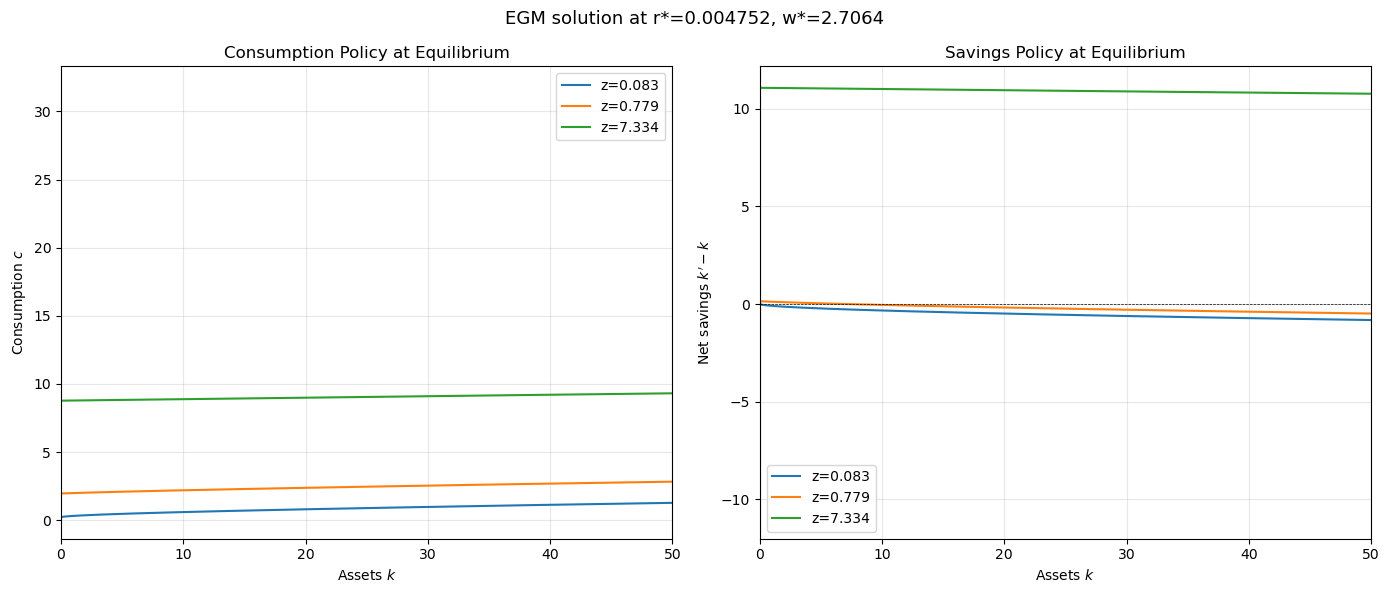

In [17]:
# Use EGM equilibrium result for baseline plots
res_egm = ge_results["EGM"]
hh_eq = res_egm["household"]
sol_eq = res_egm["solved_policy"]
z_grid = income.z_grid

# Select low, mid, high income states
z_idx = [0, ne // 2, ne - 1]
z_labels = [f"z={z_grid[i]:.3f}" for i in z_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for k, iz in enumerate(z_idx):
    ax1.plot(a_grid, sol_eq.policy_c[iz], label=z_labels[k], linewidth=1.5)
    ax2.plot(a_grid, sol_eq.policy_a[iz] - a_grid, label=z_labels[k], linewidth=1.5)

ax1.set_xlabel("Assets $k$")
ax1.set_ylabel("Consumption $c$")
ax1.set_title("Consumption Policy at Equilibrium")
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 50)

ax2.set_xlabel("Assets $k$")
ax2.set_ylabel("Net savings $k' - k$")
ax2.set_title("Savings Policy at Equilibrium")
ax2.axhline(0, color="black", linestyle="--", linewidth=0.5)
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_xlim(0, 50)

plt.suptitle(f"EGM solution at r*={res_egm['r']:.6f}, w*={res_egm['w']:.4f}", fontsize=13)
plt.tight_layout()
plt.show()

### 5.2 Wealth Distribution

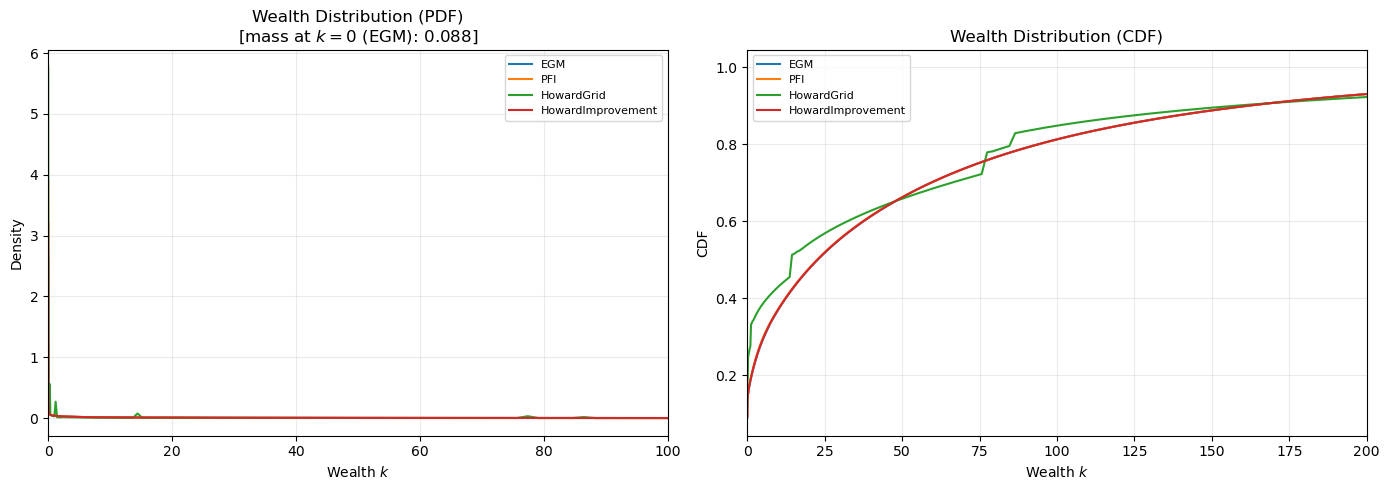

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

da = np.diff(a_grid, prepend=a_grid[0] - (a_grid[1] - a_grid[0]))

for name, res in ge_results.items():
    g = res["distribution"]
    marg = g.sum(axis=0)
    # PDF (skip atom at k=0)
    density = marg[1:] / da[1:]
    ax1.plot(a_grid[1:], density, label=name, linewidth=1.5)
    # CDF
    cdf = np.cumsum(marg)
    cdf /= cdf[-1]
    ax2.plot(a_grid, cdf, label=name, linewidth=1.5)

# Annotate borrowing constraint mass from first solver
first_name = next(iter(ge_results))
mass_at_zero = ge_results[first_name]["distribution"].sum(axis=0)[0]
ax1.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax1.set_xlim(0, 100)
ax1.set_xlabel("Wealth $k$")
ax1.set_ylabel("Density")
ax1.set_title(f"Wealth Distribution (PDF)\n[mass at $k=0$ ({first_name}): {mass_at_zero:.3f}]")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.25)

ax2.set_xlim(0, 200)
ax2.set_xlabel("Wealth $k$")
ax2.set_ylabel("CDF")
ax2.set_title("Wealth Distribution (CDF)")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 5.3 Euler Residuals

In [19]:
print("Euler residuals (unconstrained states)")
print("-" * 70)
print(f"{'Solver':<22s} {'max':>12s} {'median':>12s} {'p95':>12s}")
print("-" * 70)

for name, res in ge_results.items():
    hh = res["household"]
    euler = hh.euler_check()
    unconstrained = res["solved_policy"].policy_a > (a_grid[0] + 1e-10)
    res_unc = np.abs(euler[unconstrained])
    if res_unc.size > 0:
        print(
            f"{name:<22s} {res_unc.max():12.4e} "
            f"{np.median(res_unc):12.4e} {np.quantile(res_unc, 0.95):12.4e}"
        )
    else:
        print(f"{name:<22s} no unconstrained states")

Euler residuals (unconstrained states)
----------------------------------------------------------------------
Solver                          max       median          p95
----------------------------------------------------------------------
EGM                      1.9842e-02   4.0343e-03   1.0202e-02
PFI                      1.9720e-02   4.0277e-03   1.0157e-02
HowardGrid               3.2753e-02   4.7105e-03   1.5478e-02
HowardImprovement        1.9805e-02   4.0287e-03   1.0190e-02


### 5.4 Policy Function Comparison Across Solvers

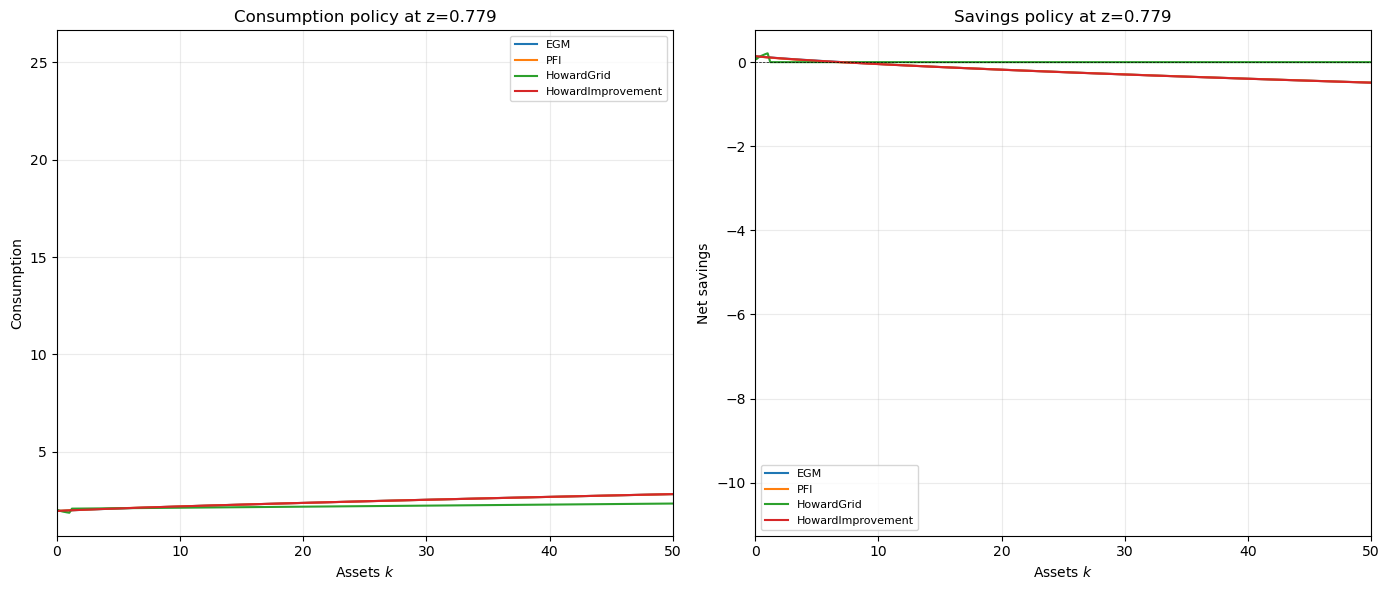

In [20]:
# Overlay at median income state
iz_mid = ne // 2
a_zoom = 50  # zoom region

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for name, res in ge_results.items():
    sol = res["solved_policy"]
    ax1.plot(a_grid, sol.policy_c[iz_mid], label=name, linewidth=1.5)
    ax2.plot(a_grid, sol.policy_a[iz_mid] - a_grid, label=name, linewidth=1.5)

ax1.set_xlim(0, a_zoom)
ax1.set_xlabel("Assets $k$")
ax1.set_ylabel("Consumption")
ax1.set_title(f"Consumption policy at z={z_grid[iz_mid]:.3f}")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.25)

ax2.set_xlim(0, a_zoom)
ax2.set_xlabel("Assets $k$")
ax2.set_ylabel("Net savings")
ax2.set_title(f"Savings policy at z={z_grid[iz_mid]:.3f}")
ax2.axhline(0, color="black", linestyle="--", linewidth=0.5)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()